<a href="https://colab.research.google.com/github/jmcoma17-tech/fasthtml-python-boilerplate/blob/main/nip_cxteam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install python-fasthtml

0/3600
1000/3600
2000/3600
3000/3600


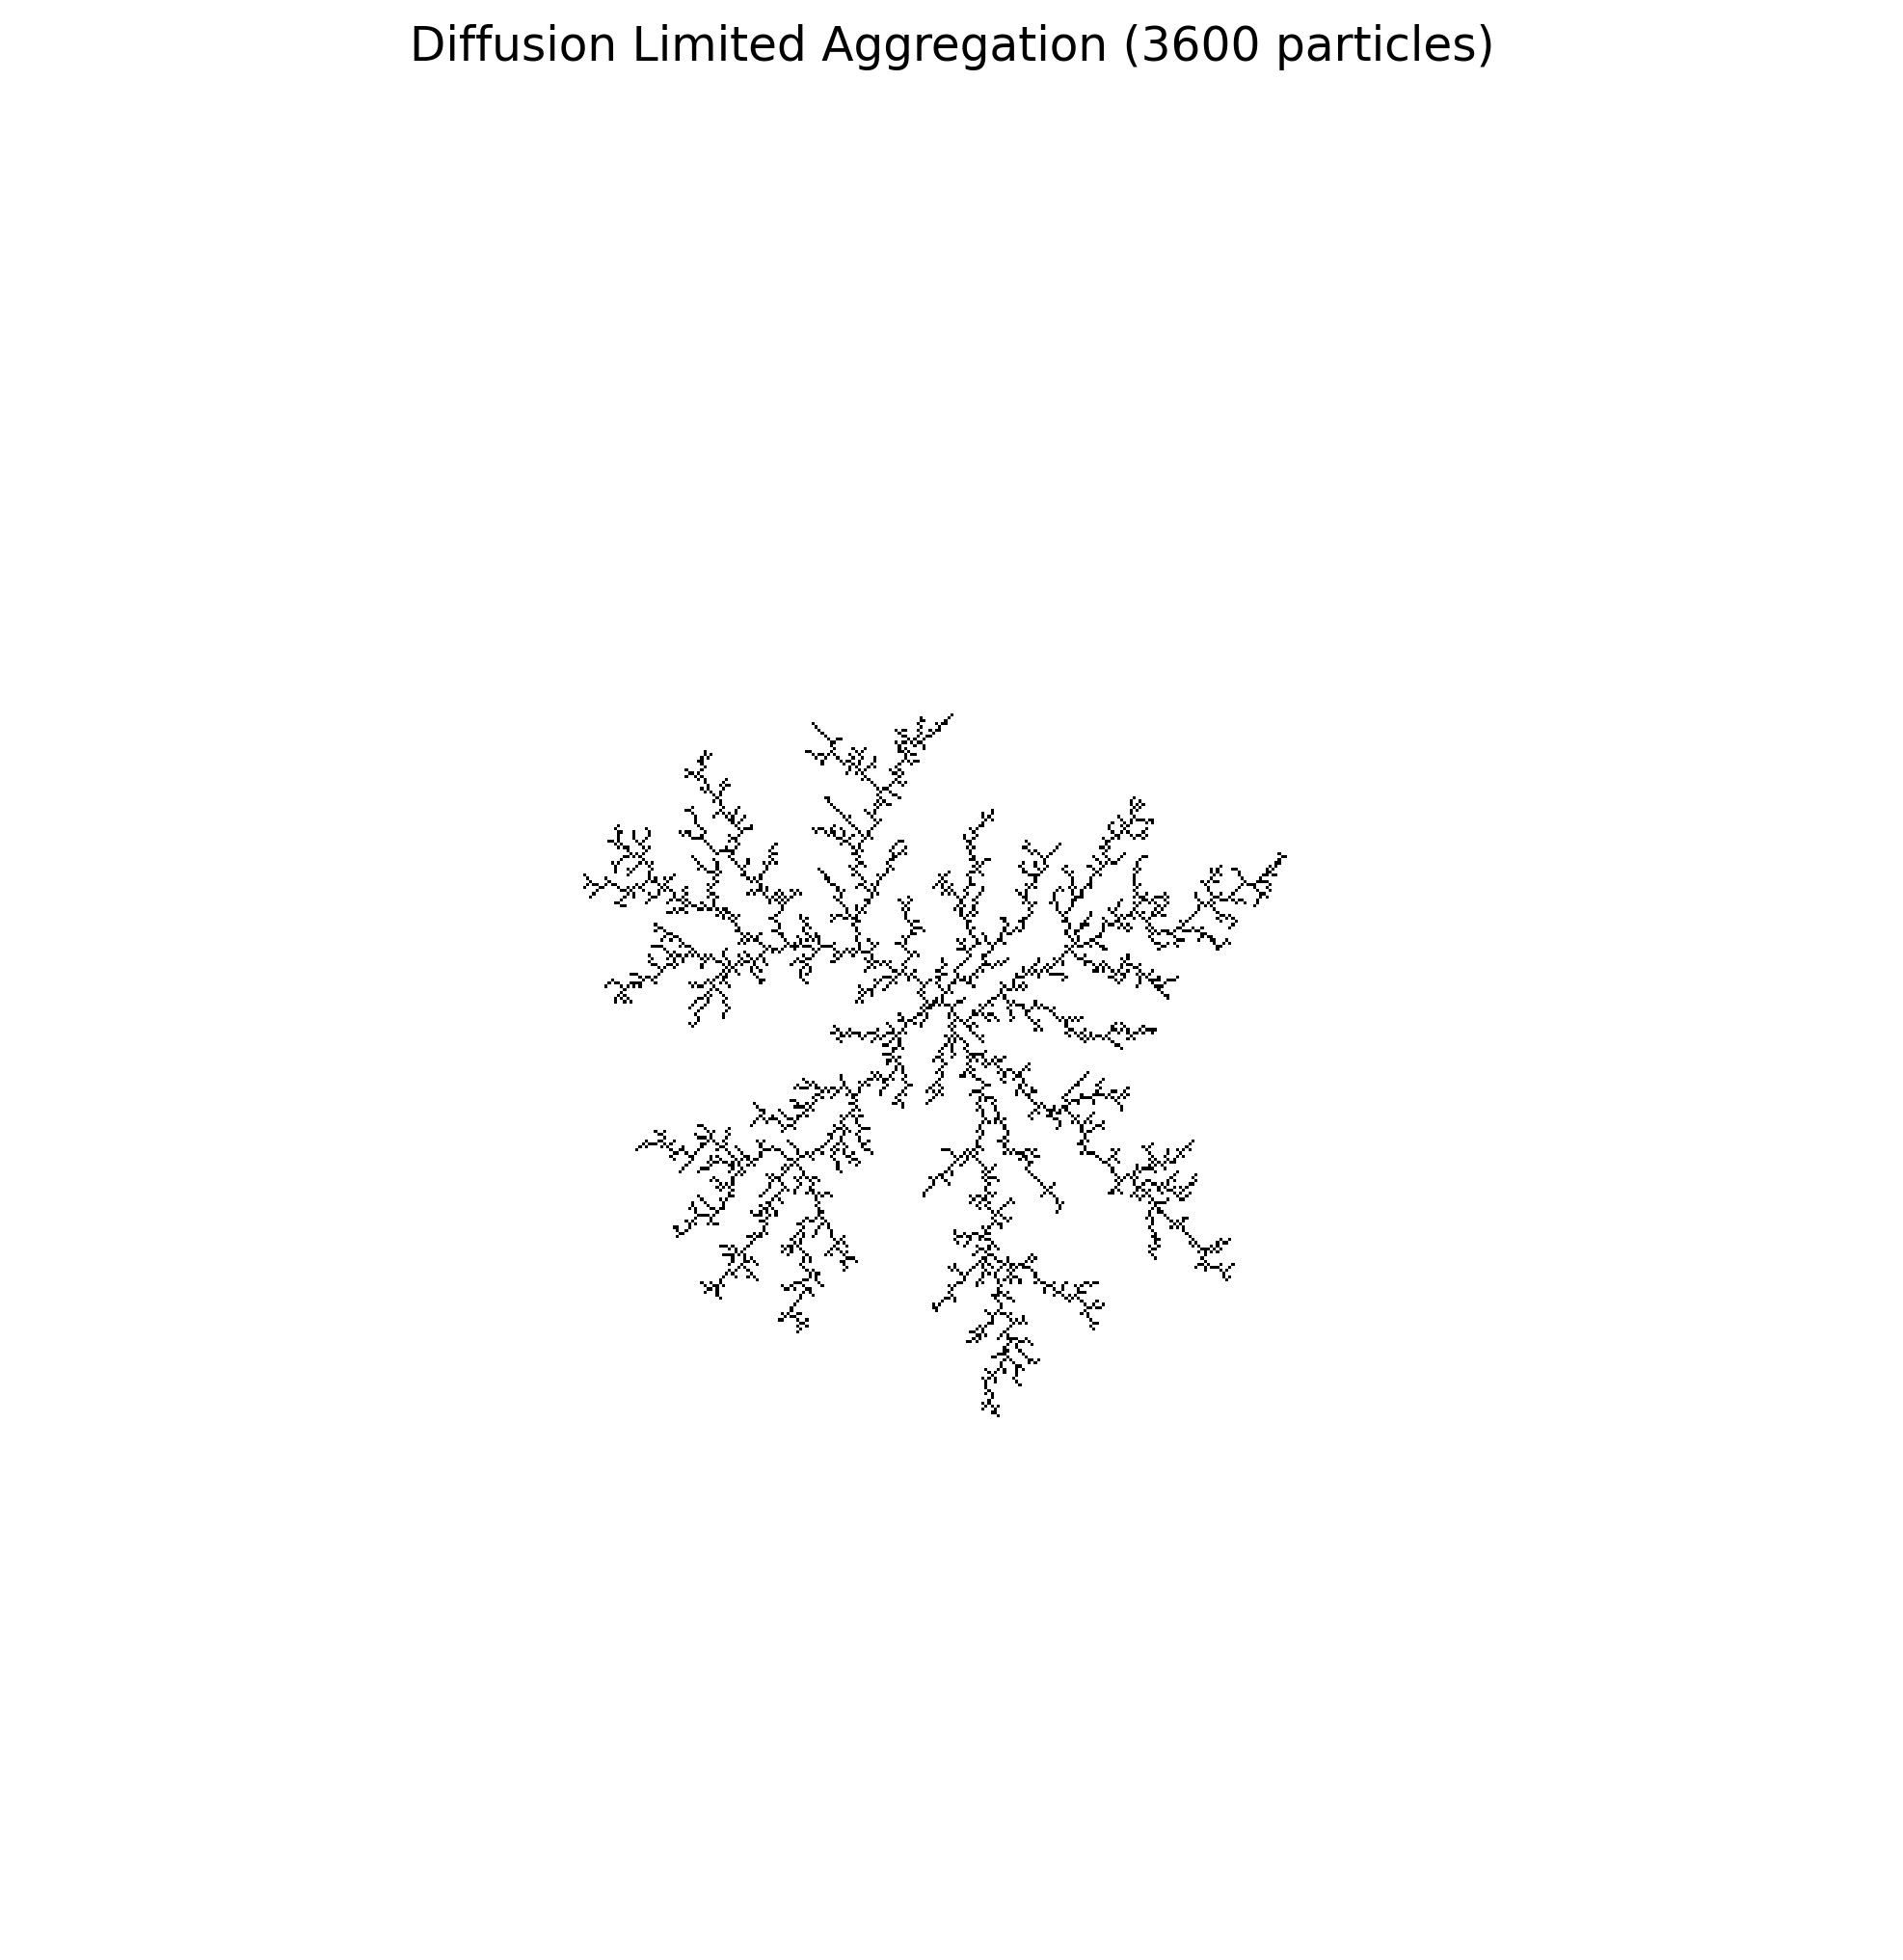

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# =====================================================
# PARAMETERS
# =====================================================

GRID_SIZE = 601
CENTER = GRID_SIZE // 2

NUM_PARTICLES = 3600

grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.uint8)

# Seed particle
grid[CENTER, CENTER] = 1

Rmax = 5
Rs = 15
Rkill = 45

# =====================================================
# RELEASE PARTICLE
# =====================================================

def occupy():
    theta = random.uniform(0, 2 * math.pi)
    x = int(Rs * math.cos(theta))
    y = int(Rs * math.sin(theta))
    return x, y

# =====================================================
# RANDOM WALK
# =====================================================

def jump(x, y):

    r = random.randint(0, 3)

    if r == 0:
        x += 1
    elif r == 1:
        x -= 1
    elif r == 2:
        y += 1
    else:
        y -= 1

    return x, y

# =====================================================
# CHECK PARTICLE
# =====================================================

def check(x, y):

    gx = x + CENTER
    gy = y + CENTER

    if gx < 2 or gx >= GRID_SIZE-2:
        return "kill"

    if gy < 2 or gy >= GRID_SIZE-2:
        return "kill"

    r = math.sqrt(x*x + y*y)

    if r > Rkill:
        return "kill"

    # 8-neighbor check
    for dx in (-1,0,1):
        for dy in (-1,0,1):

            if dx == 0 and dy == 0:
                continue

            if grid[gx+dx, gy+dy]:
                return "stick"

    return "walk"

# =====================================================
# ADD PARTICLE
# =====================================================

def aggregate(x, y):

    global Rmax, Rs, Rkill

    gx = x + CENTER
    gy = y + CENTER

    grid[gx, gy] = 1

    r = math.sqrt(x*x + y*y)

    if r > Rmax:

        Rmax = r

        # Dynamic radii
        Rs = int(Rmax + 15)
        Rkill = int(Rmax + 45)

# =====================================================
# LONG JUMP
# =====================================================

def long_jump(x, y):

    r = math.sqrt(x*x + y*y)

    if r > Rs:

        theta = random.uniform(0, 2*math.pi)

        x += int((r - Rs) * math.cos(theta))
        y += int((r - Rs) * math.sin(theta))

    return x, y

# =====================================================
# MAIN SIMULATION
# =====================================================

for particle in range(NUM_PARTICLES):

    if particle % 1000 == 0:
        print(f"{particle}/{NUM_PARTICLES}")

    x, y = occupy()

    while True:

        x, y = jump(x, y)

        result = check(x, y)

        if result == "stick":
            aggregate(x, y)
            break

        elif result == "kill":
            x, y = occupy()

        else:

            r = math.sqrt(x*x + y*y)

            # Long-jump optimization
            if r > Rs + 10:
                x, y = long_jump(x, y)

# =====================================================
# DISPLAY
# =====================================================

plt.figure(figsize=(10,10), dpi=250)

plt.imshow(
    grid,
    cmap="binary",
    origin="lower",
    interpolation="nearest"
)

plt.title(f"Diffusion Limited Aggregation ({NUM_PARTICLES} particles)", fontsize=14)

plt.axis("off")

plt.show()